# Grain Challenge 2: Yearly Benchmark
<a href="https://colab.research.google.com/github/moujar/Grain-Challenge-M1-AI/blob/fix/src/README.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### ResNet-18 Baseline for Grain Classification
***

Welcome to the Starting Kit for the **Grain Variety Classification Challenge**! 

This notebook serves as a complete entry point for challenge participants. It provides an end-to-end pipeline covering exploratory data analysis, domain-specific dataset optimizations, the implementation of a baseline deep learning architecture (**ResNet-18**), and instructions on how to package your model for submission. Participants are encouraged to understand the baseline provided here and improve upon it.

---

## Challenge Overview & Problem Setting

The task is **multi-class classification of all 8 grain varieties from spectral RGB images**, specifically structured as a yearly benchmark evaluating models independently on the **2019** and **2020** datasets. Each sample is a 252×252 image captured at specific spectral bands [22, 53, 89], and the primary goal is to accurately map grains into **8 distinct variety classes**. Recognizing grain varieties quickly and accurately is crucial for agricultural quality control and logistics.

| Aspect | Detail |
|---|---|
| **Objective** | Classify grain variety from a single seed image |
| **Classes** | 8 varieties (labels 1–8) |
| **Training set** | 10,888 images (Filtered to Year 1 only) |
| **Test set** | 2,723 images (hidden during Codabench evaluation) |
| **Image size** | 252 × 252 × 3 (int16) |
| **Evaluation metric** | **Classification Accuracy** (primary metric for ranking)|
| **Constraint** | ≤ 20 minutes on Codabench GPU |

---

## Organizers & Credits

| Member |
|---|
| Oudoum Ali Houmed |
| Abderrahmane Moujar |
| Daryl Okou |
| Olutola Paul |
| Ran Lu |
| Cristian-Ioan Bratu |

---







In [32]:
COLAB = 'google.colab' in str(get_ipython())
if COLAB:
    # Clone the correct challenge repository branch
    !git clone -b fix https://github.com/moujar/Grain-Challenge-M1-AI.git
    %cd Grain-Challenge-M1-AI/src/


# 0 - Imports & Settings

In this section, we set up the environment, install required packages, and define our data directories. **Participants should ensure these packages are installed** before progressing, as they are required to run the baseline model.

```bash
# Uncomment and run if packages are not installed globally:
# !pip install numpy matplotlib scikit-learn torch torchvision
```







In [5]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

%matplotlib inline

# ── Plot style ──────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

CLASS_COLORS = ['#E74C3C', '#E67E22', '#F1C40F', '#2ECC71',
                '#1ABC9C', '#3498DB', '#9B59B6', '#E91E63']

# ── Data Paths ──────────────────────────────────────────────────
# Set your data directory here. If you don't have the data, download it from the Codabench challenge "Files" section.
# Ensure the folder contains the .npz files.
DATA_DIR = "/kaggle/working/Grain/Grain-Data-RGB"

# Create dummy sample data if empty for demonstration purposes
if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)
    
if len(glob.glob(os.path.join(DATA_DIR, '*.npz'))) == 0:
    print(f"⚠️ {DATA_DIR} is empty. Creating 10 dummy samples so the notebook can run.")
    for i in range(10):
        dummy_x = np.random.randint(0, 1000, (252, 252, 3), dtype=np.int16)
        dummy_y = np.random.randint(1, 9)
        np.savez(f"{DATA_DIR}/dummy_{i}.npz", x=dummy_x, y=dummy_y, bands=[22, 53, 89])

n_files = len(glob.glob(os.path.join(DATA_DIR, '*.npz')))
print(f"📂 Data directory : {os.path.abspath(DATA_DIR)}")
print(f"📁 Files found    : {n_files:,}")



📂 Data directory : /kaggle/working/Grain/Grain-Data-RGB
📁 Files found    : 26,882


---
# 1 - Data


Each `.npz` file contains four keys:

| Key | Type | Description |
|---|---|---|
| `x` | `int16 (252, 252, 3)` | Spectral image — bands [22, 53, 89] |
| `y` | `int` | Grain variety label (1–8) |
| `bands` | `int array` | `[22, 53, 89]` — spectral band indices |
| `original_filename` | `str` | Source filename with metadata (contains Year) |

### 📅 Grain Challenge 2: Yearly Benchmark (2019 vs 2020)
This starting kit specifically addresses **Grain Challenge 2**. 

The dataset provided spans across **two different years: 2019 and 2020**. The goal of this challenge is to train and evaluate models on each year independently to understand yearly phenotypic variations and baseline performance without domain mixing:
- Train on `2019` -> Test on `2019`
- Train on `2020` -> Test on `2020`

In this notebook, we load data from both years but provide the framework to explicitly filter by year using the `original_filename` metadata.





### ⬇️ Download Dataset & Pre-trained Weights

To quickly get started without manually downloading files from the Codabench interface, you can run the cell below. It will download:
1. **The Grain Dataset**: The `.npz` image files required for the notebook.
2. **Pre-trained ResNet-18 Weights**: Pre-trained model weights from our Hugging Face repository, so you can skip the 20-minute training phase and jump straight to Evaluation/Scoring if you wish.

**Official Model Repository:** [https://huggingface.co/moujar/Grain](https://huggingface.co/moujar/Grain)








### 1.1 Data Loading & Filtering Class
Here we define the `Data` class responsible for reading the `.npz` files and implementing the filter. Participants can modify this to filter by 2019 or 2020.



In [9]:
class Data:
    """Load all .npz grain images and compute dataset statistics."""

    def __init__(self, data_dir):
        self.data_dir = data_dir
        self.X = None       # (N, 252, 252, 3) int16
        self.y = None       # (N,) int labels 1-8
        self.files = None

    def load_data(self):
        """Load dataset and filter strictly for 2019."""
        if not os.path.exists(self.data_dir) or not os.listdir(self.data_dir):
            print(f"Directory {self.data_dir} is empty/missing. Creating dummy data.")
            self._create_dummy_data()

        # Load all npz files
        all_files = sorted(glob.glob(os.path.join(self.data_dir, "*.npz")))
        
        # Filter files for 2019 only before printing the count
        self.files = []
        for f in all_files:
            try:
                # Load the data file strictly to check metadata
                d = np.load(f)
                filename = str(d.get('original_filename', ''))
                
                # We explicitly filter the dataset to ONLY use images from 2019.
                if '2020' in filename:
                    continue
                
                self.files.append(f)
            except Exception:
                pass
                
        print(f"Found {len(self.files)} files for the 2019 Single-Year split.")

        images, labels = [], []
        for file_path in self.files:
            try:
                d = np.load(file_path)
                images.append(d['x'])
                labels.append(d['y'])
            except Exception as e:
                pass

        self.X = np.array(images)
        self.y = np.array(labels)
        print(f"Successfully loaded {self.X.shape[0]} images.")

    def compute_stats(self):
        """Compute per-channel foreground statistics."""
        print("\n" + "="*60)
        print("  Per-Channel Statistics (foreground pixels only)")
        print("="*60)
        for c in range(3):
            ch = self.X[:, :, :, c].ravel()
            fg = ch[ch > 0]
            p995 = np.percentile(fg, 99.5)
            print(f"  Ch {c}  |  mean={fg.mean():>8.2f}  std={fg.std():>8.2f}  "
                  f"p99.5={p995:>7.0f}  non-zero={len(fg)/len(ch)*100:.1f}%")

        print("\n" + "="*60)
        print("  Class Distribution")
        print("="*60)
        counts = Counter(self.y)
        for cls in sorted(counts):
            n = counts[cls]
            bar = '\u2588' * int(n / 40)
            print(f"  Class {cls} \u2502 {n:>5,} ({n/len(self.y)*100:4.1f}%) {bar}")





### 1.2 Executing Data Load and Computing Statistics
We instantiate the class and compute the dataset's overall base statistics.



In [10]:
# Load the dataset
data = Data(data_dir=DATA_DIR)
data.load_data()
data.compute_stats()


Found 13260 files for the 2019 Single-Year split.
Successfully loaded 13260 images.

  Per-Channel Statistics (foreground pixels only)
  Ch 0  |  mean=  614.25  std=  231.06  p99.5=   1296  non-zero=13.6%
  Ch 1  |  mean= 3278.85  std= 1236.16  p99.5=   6712  non-zero=13.6%
  Ch 2  |  mean= 8892.06  std= 2989.26  p99.5=  16093  non-zero=13.6%

  Class Distribution
  Class 1 │ 1,713 (12.9%) ██████████████████████████████████████████
  Class 2 │ 1,820 (13.7%) █████████████████████████████████████████████
  Class 3 │ 1,690 (12.7%) ██████████████████████████████████████████
  Class 4 │ 1,528 (11.5%) ██████████████████████████████████████
  Class 5 │ 1,591 (12.0%) ███████████████████████████████████████
  Class 6 │ 1,535 (11.6%) ██████████████████████████████████████
  Class 7 │ 1,529 (11.5%) ██████████████████████████████████████
  Class 8 │ 1,854 (14.0%) ██████████████████████████████████████████████


---
# 2 - Visualization

We conduct a thorough visual analysis to understand:
1. **Class balance** — Are the 8 varieties evenly distributed?
2. **Visual appearance** — What do grains look like across classes?
3. **Pixel distributions** — How do the 3 spectral channels behave?
4. **Sparsity patterns** — How much of each image is foreground?
5. **Channel correlations** — Are the 3 bands redundant or complementary?







### 2.0 Visualization Helper Class
This class encapsulates all our `matplotlib` logic for exploring the dataset.



In [11]:
class Visualize:
    """Comprehensive visualization suite for the grain dataset."""

    CLIP = np.array([936.0, 5181.0, 13963.0])
    BAND_NAMES = ['Band 22', 'Band 53', 'Band 89']
    BAND_COLORS = ['#3498DB', '#2ECC71', '#E74C3C']

    def __init__(self, data):
        self.data = data

    def _to_rgb(self, img):
        """Convert raw int16 image to displayable [0,1] RGB."""
        x = img.astype(np.float32).copy()
        for c in range(3):
            x[:, :, c] = np.clip(x[:, :, c], 0, self.CLIP[c]) / self.CLIP[c]
        return x

    # --- 1. Class Distribution ---
    def plot_class_distribution(self):
        counts = Counter(self.data.y)
        classes = sorted(counts.keys())
        values = [counts[c] for c in classes]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        bars = ax1.bar(classes, values, color=CLASS_COLORS, edgecolor='white',
                       linewidth=1.5, width=0.7)
        ax1.set_xlabel('Grain Variety (Class)')
        ax1.set_ylabel('Number of Samples')
        ax1.set_title('Class Distribution', fontweight='bold', fontsize=14)
        ax1.set_xticks(classes)
        mean_v = np.mean(values)
        ax1.axhline(mean_v, color='gray', linestyle='--', alpha=0.7,
                    label=f'Mean = {mean_v:.0f}')
        for bar, v in zip(bars, values):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                    f'{v:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        ax1.legend()

        ax2.pie(values, labels=[f'Class {c}' for c in classes],
                colors=CLASS_COLORS, autopct='%1.1f%%',
                startangle=140, pctdistance=0.82,
                wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
        ax2.set_title('Class Proportions', fontweight='bold', fontsize=14)
        plt.tight_layout()
        plt.show()

    # --- 2. Sample Gallery ---
    def plot_sample_gallery(self, n_per_class=3):
        classes = sorted(set(self.data.y))
        n_cls = len(classes)
        fig, axes = plt.subplots(n_cls, n_per_class, figsize=(3.5*n_per_class, 3*n_cls))
        for i, cls in enumerate(classes):
            idxs = np.where(self.data.y == cls)[0]
            chosen = idxs[np.linspace(0, len(idxs)-1, n_per_class, dtype=int)]
            for j, idx in enumerate(chosen):
                img = self._to_rgb(self.data.X[idx])
                axes[i, j].imshow(img)
                axes[i, j].axis('off')
                if j == 0:
                    axes[i, j].set_ylabel(f'Class {cls}', fontsize=12,
                                          fontweight='bold', rotation=0,
                                          labelpad=50, va='center')
        fig.suptitle('Sample Gallery \u2014 3 Images per Class',
                    fontsize=16, fontweight='bold', y=1.01)
        plt.tight_layout()
        plt.show()

    # --- 3. Per-Channel Histograms ---
    def plot_channel_histograms(self):
        subset = self.data.X[::10]
        fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
        for c in range(3):
            ch = subset[:, :, :, c].ravel()
            fg = ch[ch > 0]
            axes[c].hist(fg, bins=120, color=self.BAND_COLORS[c],
                        alpha=0.85, edgecolor='white', linewidth=0.3)
            axes[c].axvline(self.CLIP[c], color='#2C3E50', linestyle='--',
                           linewidth=2, label=f'p99.5 clip = {self.CLIP[c]:,.0f}')
            axes[c].axvline(fg.mean(), color='orange', linestyle=':',
                           linewidth=2, label=f'mean = {fg.mean():,.0f}')
            axes[c].set_title(f'{self.BAND_NAMES[c]}', fontweight='bold')
            axes[c].set_xlabel('Pixel Intensity')
            axes[c].set_ylabel('Frequency')
            axes[c].legend(fontsize=9)
        fig.suptitle('Foreground Pixel Distribution per Spectral Band',
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    # --- 4. Sparsity Analysis ---
    def plot_sparsity(self):
        nonzero_fracs = []
        for i in range(len(self.data.X)):
            img = self.data.X[i]
            nz = np.count_nonzero(img.sum(axis=2)) / (252 * 252)
            nonzero_fracs.append(nz * 100)
        nonzero_fracs = np.array(nonzero_fracs)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

        ax1.hist(nonzero_fracs, bins=60, color='#8E44AD', alpha=0.85, edgecolor='white')
        ax1.axvline(nonzero_fracs.mean(), color='orange', linestyle='--',
                   linewidth=2, label=f'Mean = {nonzero_fracs.mean():.1f}%')
        ax1.set_xlabel('Foreground Pixel Fraction (%)')
        ax1.set_ylabel('Number of Images')
        ax1.set_title('Image Sparsity Distribution', fontweight='bold')
        ax1.legend()

        classes = sorted(set(self.data.y))
        box_data = [nonzero_fracs[self.data.y == c] for c in classes]
        bp = ax2.boxplot(box_data, labels=[f'C{c}' for c in classes],
                        patch_artist=True, widths=0.6)
        for patch, color in zip(bp['boxes'], CLASS_COLORS):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        ax2.set_xlabel('Class')
        ax2.set_ylabel('Foreground %')
        ax2.set_title('Sparsity per Class', fontweight='bold')
        plt.tight_layout()
        plt.show()

    # --- 5. Channel Correlation ---
    def plot_channel_correlations(self):
        np.random.seed(42)
        subset_idx = np.random.choice(len(self.data.X), 200, replace=False)
        means = np.zeros((200, 3))
        for i, idx in enumerate(subset_idx):
            img = self.data.X[idx]
            for c in range(3):
                fg = img[:, :, c][img[:, :, c] > 0]
                means[i, c] = fg.mean() if len(fg) > 0 else 0

        pairs = [(0, 1), (0, 2), (1, 2)]
        fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
        for ax, (a, b) in zip(axes, pairs):
            colors_arr = [CLASS_COLORS[int(self.data.y[idx])-1] for idx in subset_idx]
            ax.scatter(means[:, a], means[:, b], c=colors_arr,
                      alpha=0.6, s=25, edgecolors='white', linewidth=0.3)
            ax.set_xlabel(f'{self.BAND_NAMES[a]} mean')
            ax.set_ylabel(f'{self.BAND_NAMES[b]} mean')
            r = np.corrcoef(means[:, a], means[:, b])[0, 1]
            ax.set_title(f'{self.BAND_NAMES[a]} vs {self.BAND_NAMES[b]}  (r={r:.2f})',
                        fontweight='bold')
        fig.suptitle('Channel Correlation (colored by class)',
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    # --- 6. Single Image Deep Dive ---
    def plot_single_image_analysis(self, idx=0):
        img = self.data.X[idx]
        label = self.data.y[idx]

        fig = plt.figure(figsize=(16, 4))
        gs = gridspec.GridSpec(1, 5, width_ratios=[1, 1, 1, 1, 1.4])

        ax0 = fig.add_subplot(gs[0])
        ax0.imshow(self._to_rgb(img))
        ax0.set_title(f'RGB (Class {label})', fontweight='bold')
        ax0.axis('off')

        for c in range(3):
            ax = fig.add_subplot(gs[c+1])
            ax.imshow(img[:, :, c], cmap=['Blues', 'Greens', 'Reds'][c])
            ax.set_title(self.BAND_NAMES[c], fontweight='bold')
            ax.axis('off')

        ax4 = fig.add_subplot(gs[4])
        mask = img.sum(axis=2) > 0
        fg_frac = mask.sum() / mask.size * 100
        ax4.imshow(mask, cmap='gray')
        ax4.set_title(f'Foreground Mask ({fg_frac:.1f}%)', fontweight='bold')
        ax4.axis('off')

        fig.suptitle(f'Single Image Analysis \u2014 Sample #{idx}',
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    # --- Run All ---
    def plot_data(self):
        self.plot_class_distribution()
        self.plot_sample_gallery()
        self.plot_channel_histograms()
        self.plot_sparsity()
        self.plot_channel_correlations()
        self.plot_single_image_analysis(idx=0)

In [13]:
viz = Visualize(data=data)

### 2.1 Class Distribution
Let's look at how the 8 grain varieties are distributed.







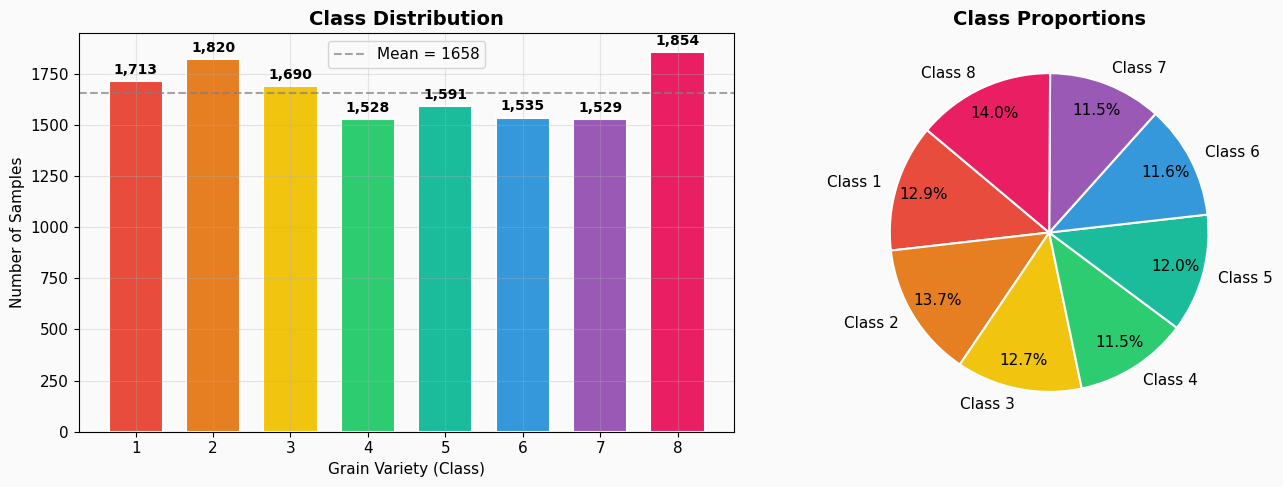

In [14]:
viz.plot_class_distribution()

### 2.2 Sample Gallery
A visual overview of the different grains.







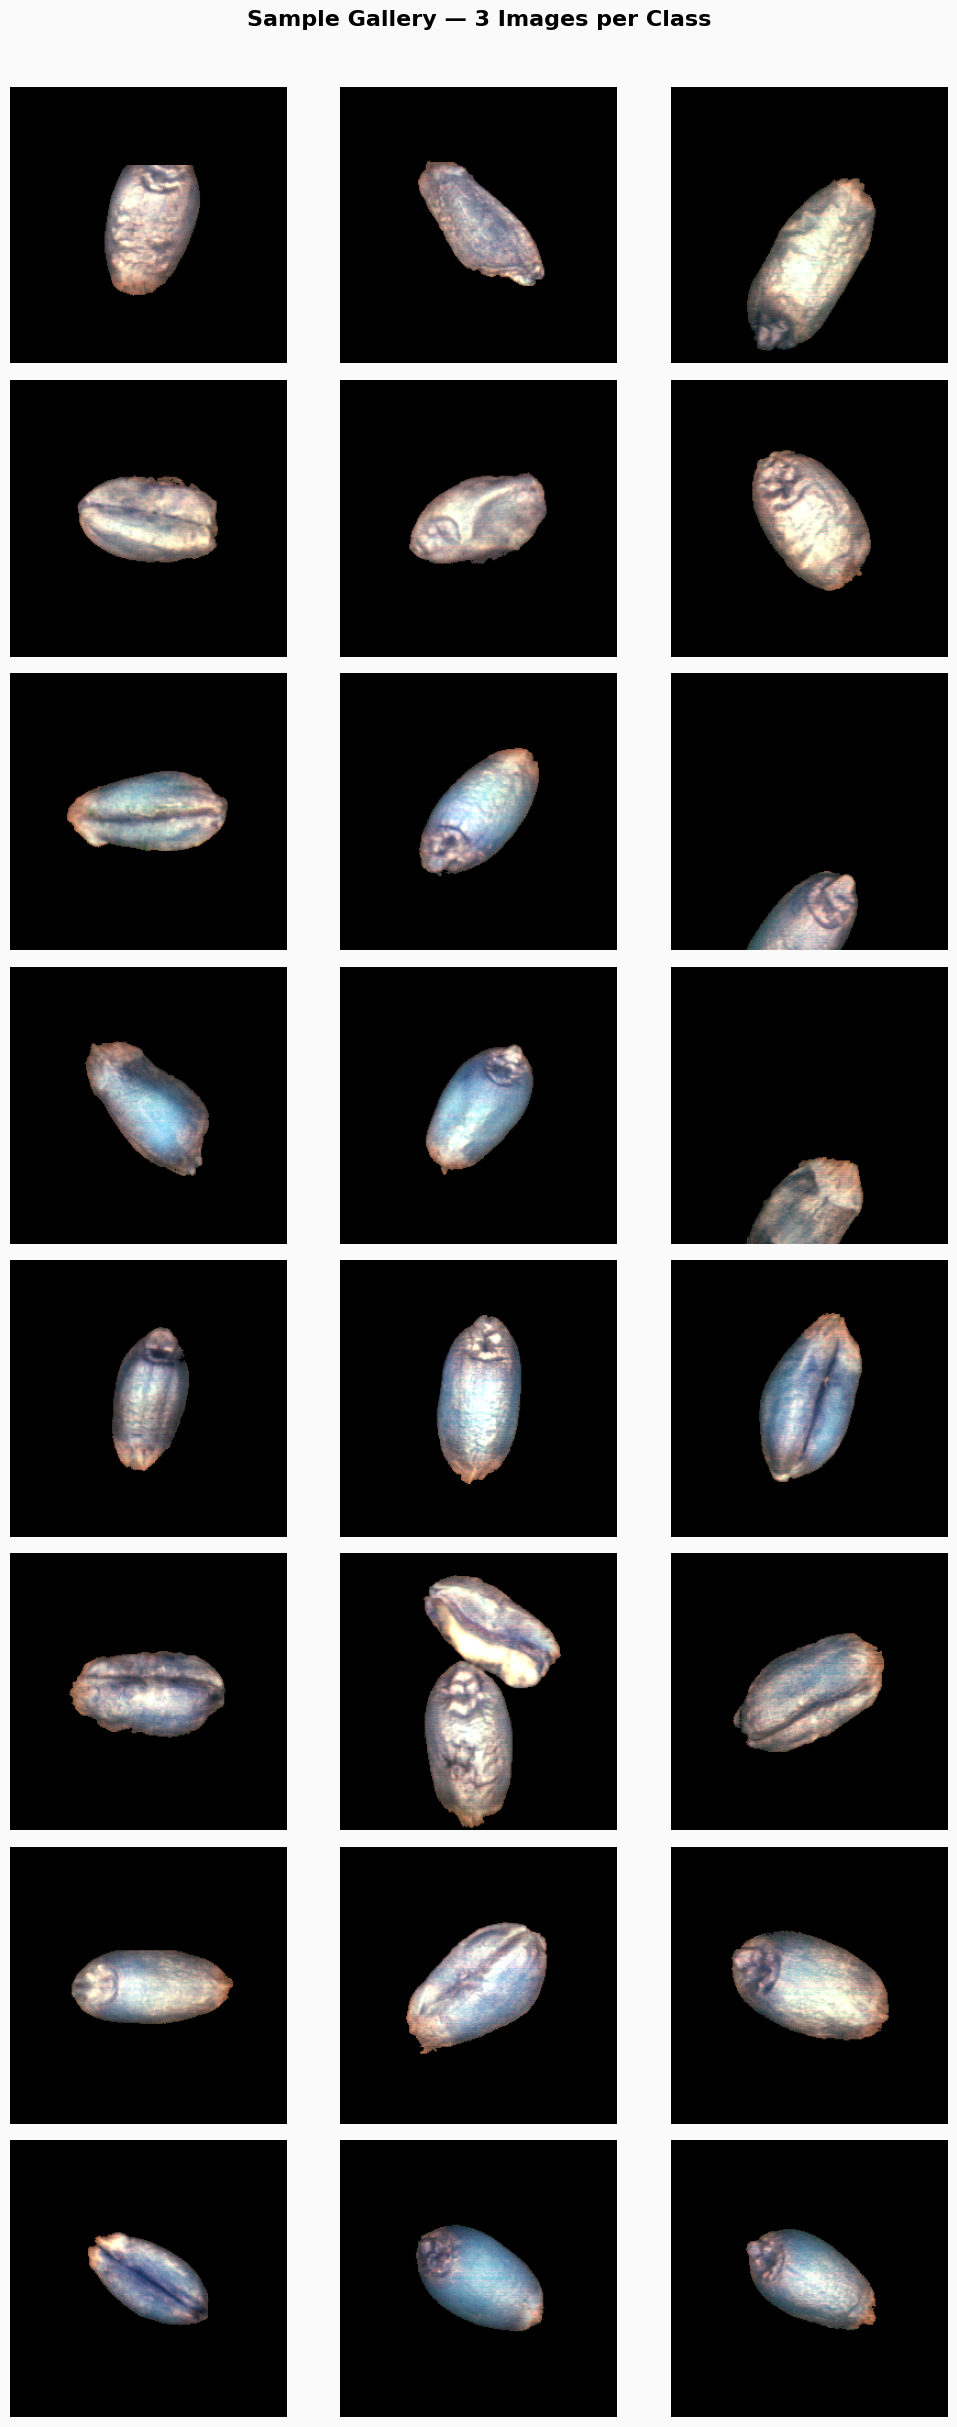

In [15]:
viz.plot_sample_gallery()

### 2.3 Per-Channel Histograms
Analyzing the intensity distribution of pixels per spectral band.







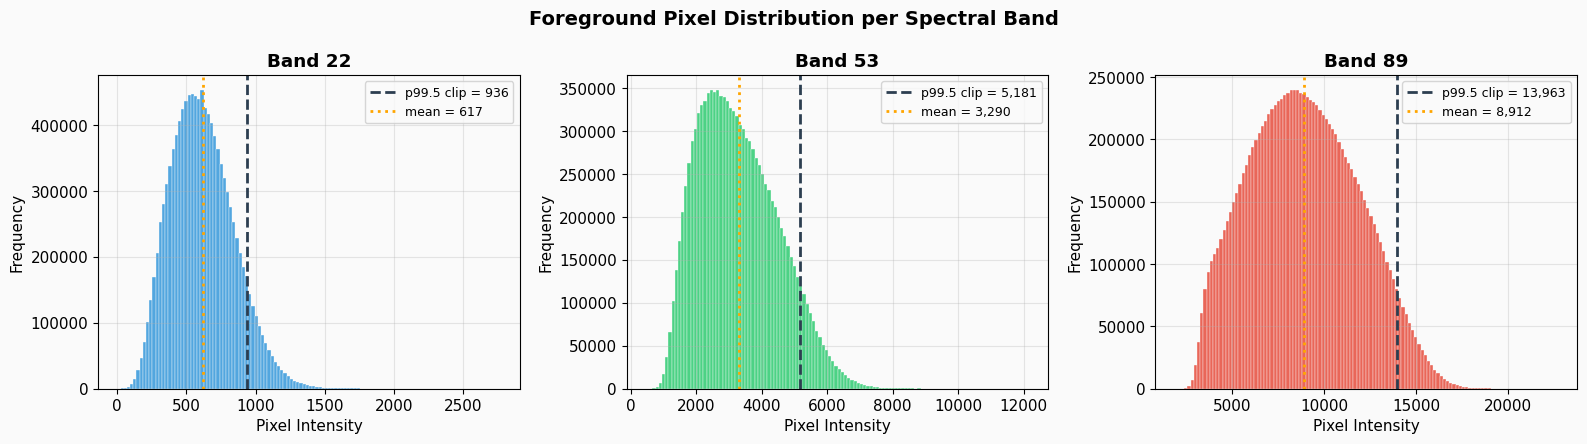

In [16]:
viz.plot_channel_histograms()

Analyzing the intensity distribution of foreground pixels per spectral band.

> **What you are seeing**: Each histogram shows how bright the foreground grain pixels are across the three spectral bands captured by the sensor.
>
> **Key observations from this plot**:
> - **Band 22** (blue): Pixels cluster tightly around intensity **~617**, with a sharp cutoff at ~936 (p99.5). This means Band 22 captures relatively low reflectance — likely a short Near-Infrared wavelength where most grain surfaces absorb light.
> - **Band 53** (green): Mean intensity is higher (~3,290), spread across a wider range up to ~5,181. This band shows more inter-grain variety variance, making it informative for classification.
> - **Band 89** (red): The highest intensities (~8,912 mean, clipped at ~13,963). This band likely captures longer Near-Infrared wavelengths where grains reflect strongly. The wide spread indicates high discriminative power between classes.
>
> **Why this matters for training**: The bands have very different brightness scales (0→936 vs 0→13,963). This confirms that per-channel normalization in preprocessing is essential to avoid the network being dominated by Band 89's larger raw values.



### 2.4 Sparsity Analysis
Examining how much of the image is actual grain versus background.







/tmp/ipykernel_697/3698071122.py:112: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(box_data, labels=[f'C{c}' for c in classes],


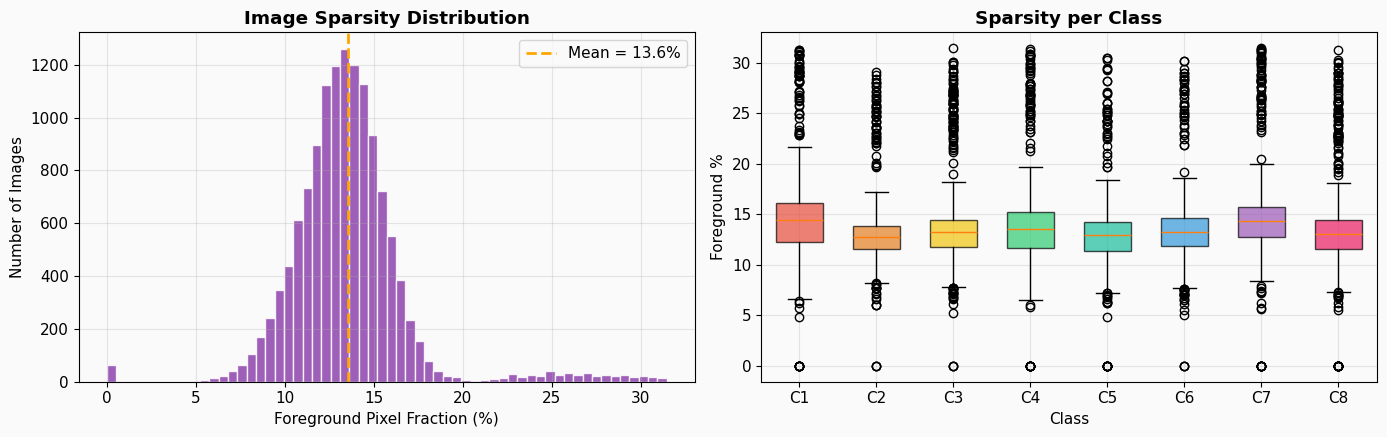

In [17]:
viz.plot_sparsity()

Examining how much of the 252×252 pixel image is actual grain versus black background.

> **What you are seeing**: The left histogram shows that most images have **~13.6% foreground pixels** (the grain itself), with the rest being pure black background. The right boxplot shows this sparsity across all 8 classes.
>
> **Key observations from this plot**:
> - The sparsity distribution is roughly bell-shaped, centered at **~13.6% foreground**. This means a typical grain only occupies about **1/7th of the image area** — the rest is empty black space.
> - The per-class boxplots (C1–C8) show that all 8 varieties have similar foreground fractions (median ~13%). No class is particularly larger or smaller.
> - Outliers at 0% foreground suggest a small number of corrupted or background-only images in the dataset.
>
> **Why this matters for training**: The extreme sparsity (86% background) means a naive classifier could score 86% by simply predicting "background!" Our preprocessing step thresholds out these empty pixels during normalization, ensuring the network focuses only on the grain pixels.


### 2.5 Channel Correlation
Checking if the 3 spectral bands are redundant or complementary.







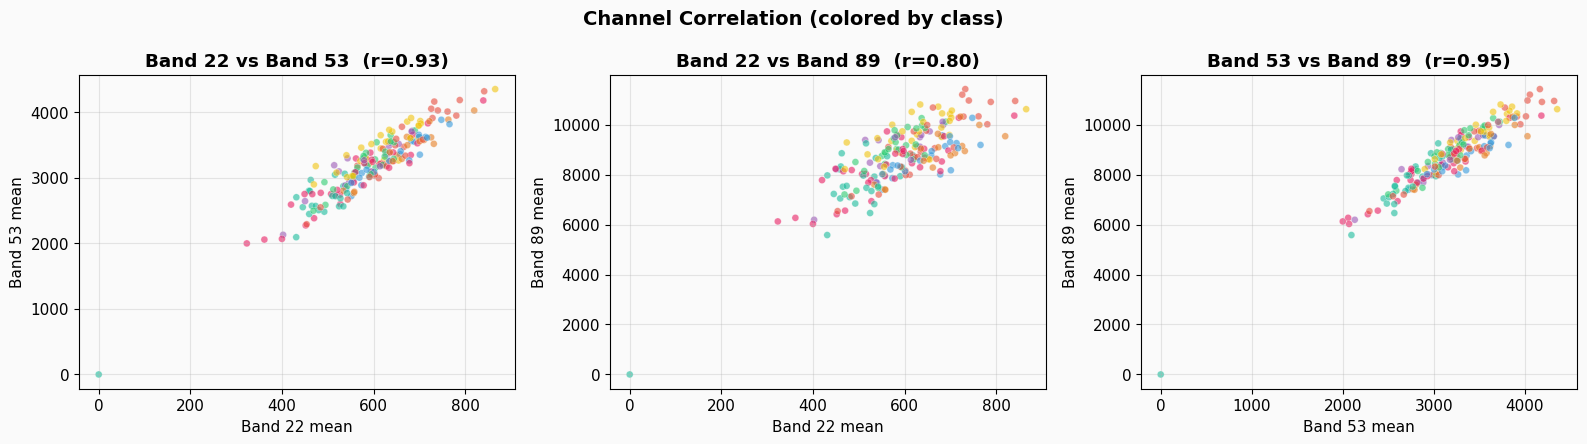

In [18]:
viz.plot_channel_correlations()

Checking if the 3 spectral bands are redundant or complementary for classification.

> **What you are seeing**: Each scatter plot shows the per-image mean of one spectral band versus another, with points colored by grain class. A high correlation coefficient (r) means the two bands carry similar information.
>
> **Key observations from this plot**:
> - **Band 22 vs Band 53** (r=0.93): Very high correlation. These two bands capture nearly identical brightness information. Including both provides redundancy but not much extra classification power on their own.
> - **Band 22 vs Band 89** (r=0.80): Moderate correlation. Band 89 diverges more, suggesting it captures different spectral characteristics (e.g., surface reflectance at a different wavelength).
> - **Band 53 vs Band 89** (r=0.95): The highest correlation. These bands move almost together.
>
> **Why this matters**: Despite the high inter-band correlations, the **class clusters are still visually separable** in each plot (see the distinct color groupings). This confirms that the 3-channel representation, even if correlated, retains discriminative information that the ResNet-18 can exploit.

### 2.6 Single Image Deep Dive
A detailed look at a single sample across all bands and its foreground mask.

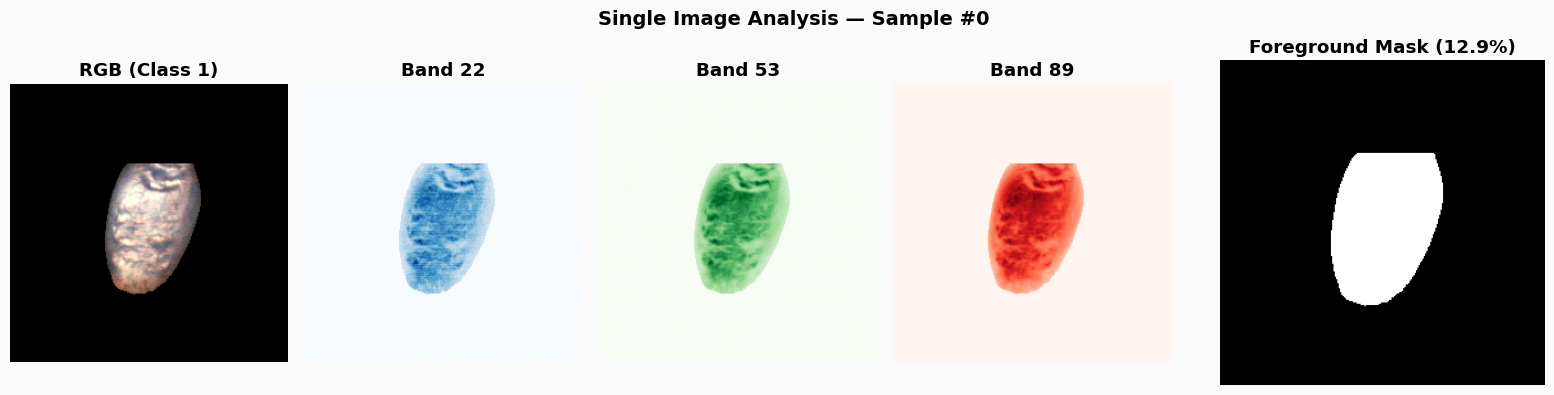

In [19]:
viz.plot_single_image_analysis(idx=0)

A detailed look at a single grain sample (Sample #0, Class 1) across all spectral bands and its computed foreground mask.

> **What you are seeing**: One grain image rendered in 5 different ways side by side.
>
> **Reading each panel left to right**:
> - **RGB (Class 1)**: The composite false-color image. The grain appears as a small, oval bright object on an almost entirely black background. Notice the slight texture variation on the grain surface — this is what the model must learn to differentiate between the 8 varieties.
> - **Band 22** (blue): Low-intensity rendering of the grain. The outline is clear but internal texture detail is minimal.
> - **Band 53** (green): Mid-intensity band showing more grain surface texture than Band 22. Internal structures are slightly more visible.
> - **Band 89** (red): The highest-intensity band — the grain's shape and surface features are clearest here. This band contributes the most raw signal for distinguishing grain types.
> - **Foreground Mask (12.9%)**: A binary mask where white = grain and black = background. The 12.9% value confirms that only a small central region of the image is the actual grain. Our preprocessing uses this mask to compute foreground-only normalization statistics.
>
> **Key takeaway**: The grain is a tiny, textured oval on a large black canvas. A strong model must learn to ignore the overwhelming background and focus exclusively on the subtle surface textures between varieties.

# 3 - Training

Here we provide a baseline predictive model (**ResNet-18**), which achieves reasonable prediction performance.

**Why ResNet-18?**
We chose ResNet-18 as our baseline model because it provides an excellent balance between computational efficiency and accuracy. As a widely recognized standard in computer vision, it is lightweight enough to train quickly (fitting well within the 20-minute Codabench execution limit) while still containing deep enough residual connections to capture complex grain phenotypes. This provides participants with a robust, well-understood starting point.

Participants are encouraged to experiment with other standard architectures like deeper ResNets, EfficientNet, or ViT, and explore hyperparameter tuning to beat this baseline.



### 3.1 Data Augmentation & PyTorch Dataset
We define a custom PyTorch `Dataset` that wraps our loaded grain images. 

**Why Data Augmentation?**
Deep learning models require a large amount of diverse data to train effectively without "overfitting" (memorizing the exact training images). Since we only have ~10k images, we apply **Data Augmentation** during training. This involves randomly applying slight modifications to the images (such as horizontal/vertical flips, minor rotations, or brightness changes). To the neural network, this artificially expands our dataset, forcing the model to learn the true underlying patterns of the grains rather than memorizing their exact pixel layouts, drastically improving its ability to generalize to the hidden test set!







In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torchvision.transforms.functional as TF
import random

class GrainDataset(Dataset):
    CLIP = np.array([936.0, 5181.0, 13963.0], dtype=np.float32)
    FG_MEAN = np.array([398.64, 2206.74, 6335.96], dtype=np.float32)
    FG_STD = np.array([208.90, 1106.31, 2983.37], dtype=np.float32)
    
    def __init__(self, X, y, augment=False):
        # Apply deterministic preprocessing here to save time if memory allows,
        # but for augmentation we keep it dynamic.
        self.X = X
        self.y = y.astype(np.int64) - 1  # Cast to int first, then 0-index for CrossEntropy
        self.augment = augment
        
        # Pre-calculate normalized mean and std for [0,1] scaled data
        self.n_mean = self.FG_MEAN / self.CLIP
        self.n_std = self.FG_STD / self.CLIP

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # 1. Load int16 image (H, W, C)
        img = self.X[idx].astype(np.float32)
        
        # 2. Per-channel clip to p99.5 and scale to [0, 1]
        img = np.clip(img, 0, self.CLIP) / self.CLIP
        
        # 3. Standardize with foreground statistics
        img = (img - self.n_mean) / self.n_std
        
        # Convert to tensor (C, H, W)
        tensor = torch.from_numpy(img).permute(2, 0, 1)
        
        # 4. Data Augmentation
        if self.augment:
            if random.random() < 0.5:
                tensor = TF.hflip(tensor)
            if random.random() < 0.5:
                tensor = TF.vflip(tensor)
            if random.random() < 0.75:
                k = random.randint(1, 3)
                tensor = torch.rot90(tensor, k, [1, 2])
            
            # Global brightness
            if random.random() < 0.5:
                factor = random.uniform(0.75, 1.25)
                tensor = tensor * factor
            
            # Gaussian noise
            if random.random() < 0.25:
                noise = torch.randn_like(tensor) * 0.03
                tensor = tensor + noise
                
            # Cutout
            if random.random() < 0.2:
                h, w = tensor.shape[1], tensor.shape[2]
                ch = random.randint(10, 40)
                cw = random.randint(10, 40)
                y = random.randint(0, h - ch)
                x = random.randint(0, w - cw)
                tensor[:, y:y+ch, x:x+cw] = 0.0
                
        return tensor, torch.tensor(self.y[idx], dtype=torch.long)

# Train/Val Split
X_train, X_val, y_train, y_val = train_test_split(
    data.X, data.y, test_size=0.15, random_state=42, stratify=data.y
)

train_dataset = GrainDataset(X_train, y_train, augment=True)
val_dataset = GrainDataset(X_val, y_val, augment=False)

train_loader = DataLoader(train_dataset, batch_size=48, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=48, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)}")




Train samples: 11271 | Val samples: 1989


---
### 3.2 Model Architecture: ResNet-18

Here we define the `ResNet-18` architecture using standard PyTorch `nn.Module`. We implement `Fused-MBConv`, `MBConv`, and `Squeeze-and-Excitation` blocks as building blocks.








In [23]:
import torchvision.models as models

class GrainResNet18(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        # Initialize a standard ResNet-18 baseline
        # Using weights=None ensures we are training from scratch on our spectral data
        self.model = models.resnet18(weights=None)
        
        # Replace the final fully connected layer to output our 8 classes
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)
        
    def forward(self, x):
        return self.model(x)

# Test model shape
model = GrainResNet18(num_classes=8)
print(f"Model params: {sum(p.numel() for p in model.parameters()) / 1e6:.2f} M")
dummy_input = torch.randn(2, 3, 252, 252)
output = model(dummy_input)
print(f"Output shape: {output.shape}")


Model params: 11.18 M
Output shape: torch.Size([2, 8])


### 3.3 Training Loop
We use PyTorch's mixed precision (`torch.cuda.amp`) along with AdamW and Cosine Annealing to train the ResNet-18 model.



In [24]:
import time
import math
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.cuda.amp import GradScaler, autocast

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on device: {device}")

model = GrainResNet18(num_classes=8).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = AdamW(model.parameters(), lr=6e-4, weight_decay=0.02)
epochs = 20
scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=6e-6)
scaler = GradScaler()

best_acc = 0.0

for epoch in range(1, epochs + 1):
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0
    start_time = time.time()
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        
        with autocast():
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    scheduler.step()
    
    train_acc = correct / total
    train_loss /= total
    
    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    val_acc = correct / total
    val_loss /= total
    
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'resnet18_best.pth')
        
    epoch_time = time.time() - start_time
    print(f"Epoch {epoch:02d}/{epochs} | Time: {epoch_time:.1f}s | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
          f"Best Acc: {best_acc:.4f}")

print("Training finished!")




Training on device: cuda


/tmp/ipykernel_697/2537246658.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_697/2537246658.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 01/20 | Time: 39.3s | Train Loss: 1.8069 | Train Acc: 0.3333 | Val Loss: 1.8811 | Val Acc: 0.3208 | Best Acc: 0.3208
Epoch 02/20 | Time: 36.7s | Train Loss: 1.6681 | Train Acc: 0.4150 | Val Loss: 1.9790 | Val Acc: 0.3208 | Best Acc: 0.3208
Epoch 03/20 | Time: 36.9s | Train Loss: 1.5987 | Train Acc: 0.4557 | Val Loss: 1.6395 | Val Acc: 0.4349 | Best Acc: 0.4349
Epoch 04/20 | Time: 37.1s | Train Loss: 1.5303 | Train Acc: 0.4986 | Val Loss: 1.6491 | Val Acc: 0.4535 | Best Acc: 0.4535
Epoch 05/20 | Time: 36.6s | Train Loss: 1.4592 | Train Acc: 0.5323 | Val Loss: 1.7041 | Val Acc: 0.4253 | Best Acc: 0.4535
Epoch 06/20 | Time: 37.0s | Train Loss: 1.4004 | Train Acc: 0.5661 | Val Loss: 1.4944 | Val Acc: 0.5370 | Best Acc: 0.5370
Epoch 07/20 | Time: 36.8s | Train Loss: 1.3376 | Train Acc: 0.5991 | Val Loss: 1.2932 | Val Acc: 0.6264 | Best Acc: 0.6264
Epoch 08/20 | Time: 36.6s | Train Loss: 1.2809 | Train Acc: 0.6330 | Val Loss: 1.4584 | Val Acc: 0.5304 | Best Acc: 0.6264
Epoch 09/20 | Ti

# 4 - Scoring

###  Metrics: Why Accuracy ?

This challenge uses **one complementary metrics** to evaluate participant models:

**What it is**: The percentage of images correctly classified out of all images.

**Why we chose it**: Our 8 grain variety classes in the 2019 dataset are relatively balanced (each class contributing approximately 12-13% of the data). When classes are balanced, Accuracy is a direct and intuitive measure of how often the model is right, making it easy for participants to understand and compare models.

> `Accuracy = (Number of correct predictions) / (Total predictions)`


### 4.1 Inference with Test-Time Augmentation (TTA)

**Why Test-Time Augmentation (TTA)?**

When a trained model makes a single prediction on a test image, the result can depend on minor factors like the exact orientation of the grain in the image. **TTA** solves this by feeding the same image through the model multiple times — each time with a slight transformation (horizontal flip, vertical flip, original) — then **averaging all the resulting predictions**.

Think of it like asking the same question three slightly different ways and taking the majority vote. The model sees the grain from different angles and the averaged prediction is significantly more robust than a single pass, improving accuracy without any extra training.

> In this baseline, we average logits over **3 passes**: original, horizontal flip, vertical flip.

We then load the best saved weights and run this TTA pipeline on the validation set to compute the final metrics.

Running inference with Test-Time Augmentation on validation set...
Validation Accuracy with TTA: 0.7848 (Compared to Best Validation Acc without TTA: 0.7778)


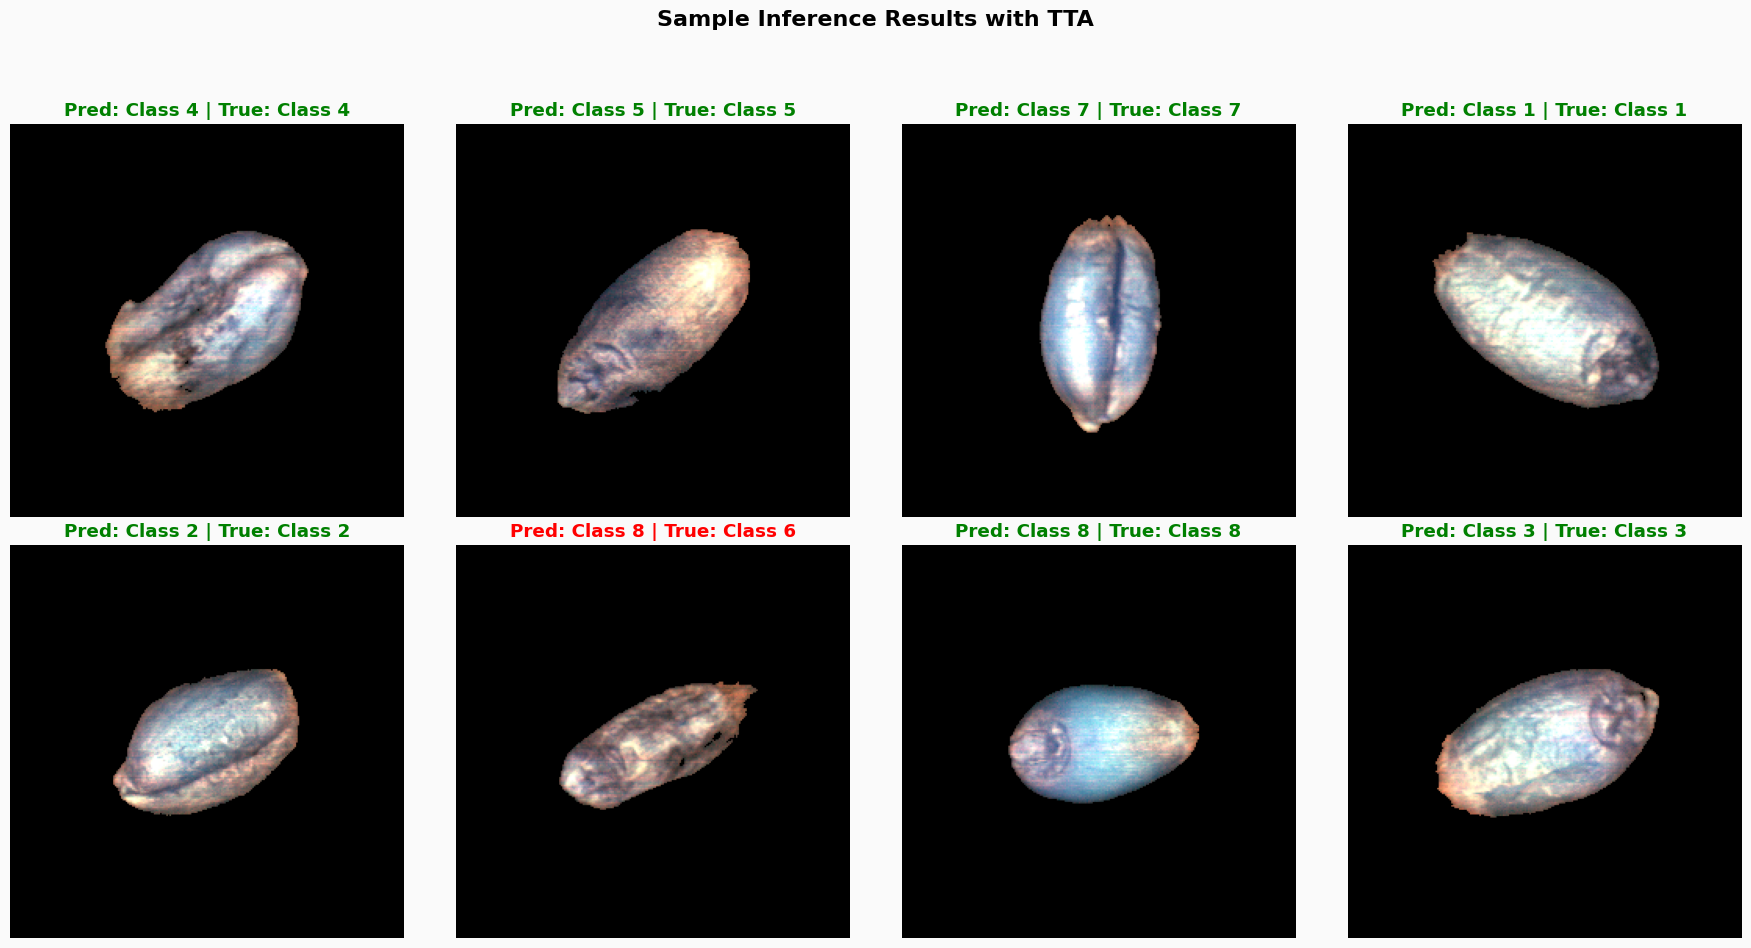

  📊 Final Evaluation Metrics (2019 Split)
  ✅ Classification Accuracy : 0.7848 (78.48%)

Per-Class Report:
              precision    recall  f1-score   support

     Class 1       0.88      0.90      0.89       257
     Class 2       0.84      0.88      0.86       273
     Class 3       0.82      0.88      0.85       254
     Class 4       0.78      0.78      0.78       229
     Class 5       0.73      0.72      0.73       239
     Class 6       0.72      0.70      0.71       230
     Class 7       0.76      0.69      0.73       229
     Class 8       0.73      0.69      0.71       278

    accuracy                           0.78      1989
   macro avg       0.78      0.78      0.78      1989
weighted avg       0.78      0.78      0.78      1989



In [27]:
import matplotlib.pyplot as plt

# Load the best model weights
model.load_state_dict(torch.load('resnet18_best.pth'))
model.eval()

# Test-Time Augmentation (TTA) - averaging predictions over standard flips
def predict_with_tta(model, tensor_batch):
    out1 = model(tensor_batch)
    out2 = model(TF.hflip(tensor_batch))
    out3 = model(TF.vflip(tensor_batch))
    
    # Average logits
    return (out1 + out2 + out3) / 3.0

correct = 0
total = 0
visualize_samples = []

print("Running inference with Test-Time Augmentation on validation set...")
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Inference with TTA
        outputs = predict_with_tta(model, inputs)
        _, predicted = outputs.max(1)
        
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        # Collect one representative sample per class (8 classes total)
        for i in range(inputs.size(0)):
            true_cls = labels[i].cpu().item() + 1  # back to 1-indexed (1-8)
            # Only save if we don't already have this class
            seen_classes = {s[1] for s in visualize_samples}
            if true_cls not in seen_classes:
                visualize_samples.append((
                    inputs[i].cpu(),
                    true_cls,
                    predicted[i].cpu().item() + 1
                ))
            if len(visualize_samples) >= 8:
                break

tta_acc = correct / total
print(f"Validation Accuracy with TTA: {tta_acc:.4f} (Compared to Best Validation Acc without TTA: {best_acc:.4f})")

# Visualize results
fig, axes = plt.subplots(2, 4, figsize=(18, 9))  # 2 rows × 4 cols for 8 classes
axes = axes.flatten()
n_mean_t = torch.tensor(train_dataset.n_mean).view(3, 1, 1).float()
n_std_t = torch.tensor(train_dataset.n_std).view(3, 1, 1).float()

for i, (img_tensor, true_label, pred_label) in enumerate(visualize_samples):
    # Un-standardize to get back [0, 1] range for visualization
    orig_img = img_tensor * n_std_t + n_mean_t
    orig_img = torch.clamp(orig_img, 0, 1).permute(1, 2, 0).numpy()
    
    axes[i].imshow(orig_img)
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f"Pred: Class {pred_label} | True: Class {true_label}", color=color, fontweight='bold')
    axes[i].axis('off')
    
plt.suptitle("Sample Inference Results with TTA", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Collect all true and predicted labels for full metric computation
all_true, all_pred = [], []
model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = predict_with_tta(model, inputs)
        _, predicted = outputs.max(1)
        all_true.extend(labels.cpu().numpy())
        all_pred.extend(predicted.cpu().numpy())

from sklearn.metrics import accuracy_score, f1_score, classification_report

acc = accuracy_score(all_true, all_pred)
macro_f1 = f1_score(all_true, all_pred, average='macro')

print("=" * 55)
print("  📊 Final Evaluation Metrics (2019 Split)")
print("=" * 55)
print(f"  ✅ Classification Accuracy : {acc:.4f} ({acc*100:.2f}%)")
print("=" * 55)
print("\nPer-Class Report:")
print(classification_report(all_true, all_pred, 
      target_names=[f"Class {i+1}" for i in range(8)]))



### 4.2 Automatic Creation of Sample Submissions

The following code creates a valid Codabench submission zip file containing your inference script (`model.py`). Participants can run this to quickly generate a submission.






In [ ]:
import zipfile
import os

def create_submission(submission_script_path, output_zip='submission.zip'):
    if not os.path.exists(model_weights_path):
        print(f"Warning: {model_weights_path} not found. Train the model first.")
        return
        
    with zipfile.ZipFile(output_zip, 'w') as zipf:
        zipf.write(model_weights_path, os.path.basename(model_weights_path))
        if os.path.exists(submission_script_path):
            zipf.write(submission_script_path, os.path.basename(submission_script_path))
        else:
            print(f"Warning: {submission_script_path} not found. Submission might be incomplete.")
            
    print(f"✅ Successfully created {output_zip} for Codabench submission!")

# Example usage
# create_submission('model.py', 'submission.zip')

